# Portfolio Piece 1: Evaluating Sentiment Model Robustness Across IMDB Movie Genre Subdomains
This project is extending on the concepts and experiments we conducted for lab 1. Models often look strong on the data they were trained on, but degrade on slightly different data distributions (domain shift). Here we treat "genre language" as a controlled domain shift.

In [72]:
# Import necessary modules and packages
import os
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

## 0. Paths and Dataset Downloads
We define consistent file paths relative to the **project root** and automatically download the IMDB dataset if it’s not already available locally.

In [73]:
# Move one level up from the notebook directory so paths work from /notebooks
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIRECTORY = os.path.join(PROJECT_ROOT, "src")
DATASET_FOLDER = os.path.join(DATA_DIRECTORY, "aclImdb") 
ARCHIVE_PATH = os.path.join(DATA_DIRECTORY, "aclImdb_v1.tar.gz")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

# Create the data and output directory if it doesn't exist (safe to run multiple times)
os.makedirs(DATA_DIRECTORY, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Checking IMDB dataset...")

# If the extracted dataset folder doesn't exist, download + extract
if not os.path.exists(DATASET_FOLDER):
    print("Downloading IMDB dataset (this may take a minute)...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, ARCHIVE_PATH)

    # Extract the archive into DATA_DIRECTORY so we get DATA_DIRECTORY/aclImdb/...
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIRECTORY)

    print("✓ Download complete.")
else:
    print("✓ Dataset already available.")


Checking IMDB dataset...
✓ Dataset already available.


## 1. Loading a Balanced Subset of IMDB Reviews
We load a balanced sample of positive and negative reviews from the IMDB. # - The full IMDB dataset contains 25,000 training reviews. For faster experimentation (Lab 1 level), we use a smaller subset. We intentionally load an equal number of positive and negative reviews so the dataset is balanced. This will give us more accurate and meaningful results. We also shuffle the data to remove any ordering effects (e.g., all positives first).


We begin by loading a balanced subset of positive and negative reviews from the IMDB training data.

The full IMDB dataset contains `25,000 labeled training reviews`. For faster experimentation and clearer iteration similar to what we did in Lab 1, we use a smaller subset while preserving class balance. Specifically, we load an equal number of positive and negative reviews. Maintaining a balanced dataset is important because it ensures that accuracy is an informative evaluation metric. Imbalanced datasets can result in skewed results where the majority class can be favored to produce high accuracy results. By keeping the dataset balanced, we reduce this risk and make performance comparisons more meaningful and accurate.

Finally, we shuffle the dataset after loading. This prevents any ordering effects (such as all positive reviews appearing before negative ones) from influencing downstream splitting or model training similar to what we do with a new deck of cards.

In [74]:
def load_imdb_data(path, num_samples=2500):
    reviews = []

    # Define paths to positive and negative training folders
    pos_path = os.path.join(path, "train", "pos")
    neg_path = os.path.join(path, "train", "neg")

    # Load positive reviews
    for filename in os.listdir(pos_path)[:num_samples]:
        with open(os.path.join(pos_path, filename), "r", encoding="utf-8") as f:
            reviews.append({"review": f.read(), "sentiment": "positive"})

    # Load negative reviews
    for filename in os.listdir(neg_path)[:num_samples]:
        with open(os.path.join(neg_path, filename), "r", encoding="utf-8") as f:
            reviews.append({"review": f.read(), "sentiment": "negative"})

    return reviews

# Load 2,500 positive and 2,500 negative reviews (5,000 total)
reviews_data = load_imdb_data(DATASET_FOLDER, num_samples=2500)

# Convert to DataFrame for easier data manipulation and transformation
data = pd.DataFrame(reviews_data)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total reviews loaded:", len(data))
print(data["sentiment"].value_counts())

Total reviews loaded: 5000
sentiment
positive    2500
negative    2500
Name: count, dtype: int64


## 2. Train/Test Split — General → General Baseline
To establish a performance benchmark, we split the dataset into `training (80%)` and `test (20%)` sets using stratified sampling (divide a bigger population into subgroups). Stratification ensures that the proportion of positive and negative reviews remains consistent across both splits.

This step serves two purposes:
1. It prevents data leakage by ensuring the model is evaluated on unseen data.
2. It provides a baseline performance estimate when training and testing occur under the same distribution.

This “General → General” evaluation represents the ideal scenario in which no domain shift is present. Any performance degradation observed later in genre-specific experiments can therefore be attributed to distributional differences rather than model instability.

In [75]:
# Separate features (X) and labels (y). We explicitly cast review text to string to avoid unexpected type issues.
X = data["review"].astype(str)

# Map labels to numeric format for modeling
y = data["sentiment"].map({"negative": 0, "positive": 1})  # 0=negative, 1=positive

# Perform stratified train/test split to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train label balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test label balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train size: 4000 Test size: 1000
Train label balance: {1: 0.5, 0: 0.5}
Test label balance: {0: 0.5, 1: 0.5}


## 3. Constructing Genre Subsets via Weak Supervision

The IMDB dataset used in this project does not include explicit genre metadata. To simulate genre-specific subdomains, we construct genre labels using a simple keyword-based weak supervision strategy.

For each predefined genre (horror, comedy, romance, and action), we define a small set of representative keywords. If a review contains one or more of these keywords, it is assigned to the corresponding genre subset. Reviews that do not match any predefined keywords are assigned `NaN` (no genre), since we intentionally restrict our analysis to a limited set of subdomains.

This approach serves several purposes:
- It allows us to approximate genre-based domain shifts without requiring manual annotation.
- It mirrors real-world scenarios where labeled metadata may be inconsistent, incomplete, or noisy.
- It provides a transparent and interpretable way to create controlled subdomains for experimentation.

Importantly, this method introduces label noise. A review may contain genre-related keywords without truly belonging to that genre, and some reviews may match multiple genres. To simplify the experimental setup (consistent with the Lab 1 level), we assign each review a single “primary genre” based on the first keyword match.

These genre assignments are not intended to be perfect. Rather, they create structured subsets that differ lexically from the overall dataset, enabling analysis of domain shift effects.


In [76]:
# 2) Weak supervision: Genre keyword rules

GENRE_KEYWORDS = {
    "horror":  ["horror", "scary", "gore", "monster", "creepy", "slasher", "terrifying", "fright"],
    "comedy":  ["comedy", "funny", "hilarious", "laugh", "jokes", "humor"],
    "romance": ["romance", "romantic", "love story", "relationship", "couple", "chemistry"],
    "action":  ["action", "fight", "explosion", "chase", "gun", "war", "battle"]
}

def assign_genres(text: str, genre_keywords: dict) -> list:
    #Return list of matching genres for a review based on presence of keywords
    text_lower = text.lower()
    matches = []
    for genre, kws in genre_keywords.items():
        # phrase match; simple and transparent
        if any(kw in text_lower for kw in kws):
            matches.append(genre)
    return matches

# Apply weak supervision rules to create a multi-label genre column (review can match multiple genres)
data["genres"] = data["review"].astype(str).apply(lambda t: assign_genres(t, GENRE_KEYWORDS))

# For experimental simplicity, assign a single "primary_genre".
data["primary_genre"] = data["genres"].apply(lambda g: g[0] if len(g) > 0 else None)

print("Genre counts (primary):")
print(data["primary_genre"].value_counts(dropna=False))


Genre counts (primary):
primary_genre
NaN        1526
comedy     1263
action     1003
horror      778
romance     430
Name: count, dtype: int64


## 4. Feature Representation and Model Training (TF-IDF + Naive Bayes)

To convert text reviews into numerical features, we use TF-IDF (Term Frequency–Inverse Document Frequency) that we learned from in our lab 1. This representation reduces the influence of very common words while emphasizing words that are more informative for classification.

The TF-IDF vectorizer is fit only on the training data to prevent data leakage.

For classification, we use a Multinomial Naive Bayes model. This model performs well with sparse text features, is computationally efficient, and provides a clear and interpretable baseline.

The goal is not to optimize performance with complex architectures, but to evaluate robustness under domain variation using a simple, transparent model.


In [77]:
# 3) Train Naive Bayes classifier on TF-IDF features
def train_nb_tfidf(train_text, train_y):
    # Convert raw text into numerical TF-IDF features
    vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", max_features=30000, ngram_range=(1, 2), min_df=2)
    
    # Learn vocabulary + IDF weights from training data only
    Xtr = vectorizer.fit_transform(train_text)

    model = MultinomialNB()
    model.fit(Xtr, train_y)
    return vectorizer, model

# Model evaluation function to compute accuracy and print classification report
def evaluate(model, vectorizer, test_text, test_y, label=""):
    
    # Transform test text using the already-fitted vectorizer
    Xte = vectorizer.transform(test_text)

    # Generate predictions and evaluate accuracy + classification report
    pred = model.predict(Xte)
    acc = accuracy_score(test_y, pred)
    print(f"\n--- {label} ---")
    print("Accuracy:", round(acc, 4))
    print(classification_report(test_y, pred, target_names=["negative","positive"]))
    return acc

## 5. Setting A — General → General (Baseline Model Performance)

In this first experiment, we train the TF-IDF + Naive Bayes model on the general training set and evaluate it on the general test set. Because both sets are drawn from the same overall distribution, this represents the no-domain-shift condition. The resulting accuracy serves as our baseline benchmark.

All subsequent genre-based evaluations will be compared against this baseline to measure the magnitude of performance degradation under domain shift.

In [78]:
# Train TF-IDF + Naive Bayes on general training data
vec_general, nb_general = train_nb_tfidf(X_train, y_train)

# Evaluate on general test data (General → General setup)
acc_general = evaluate(nb_general, vec_general, X_test, y_test, label="General → General")


--- General → General ---
Accuracy: 0.906
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91       500
    positive       0.93      0.88      0.90       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



## 6. Setting B — Subset → Subset (In-Domain Evaluation)
In this setting, we train and evaluate the model within the same genre-specific subset.

For each genre (e.g., horror, comedy, romance, etc), we:
- Extract reviews assigned to that genre,
- Split them into training and test sets,
- Train a TF-IDF + Naive Bayes model on that subset,
- Evaluate performance on the corresponding subset test data.

This represents an *in-domain* condition, where the training and test distributions are aligned. It allows us to measure how well sentiment can be learned when genre language is consistent.

In [ ]:
def get_genre_subset(df: pd.DataFrame, genre: str) -> pd.DataFrame:
    #Return reviews assigned to a given primary genre
    return df[df["primary_genre"] == genre].copy()

results = []

# Store each genre's test set so Setting C can reuse the exact same observations
genre_test_sets = {}

for genre in GENRE_KEYWORDS.keys():
    subset = get_genre_subset(data, genre)

    # Skip very small subsets to avoid unstable accuracy estimates
    if len(subset) < 200:
        print(f"\nSkipping {genre}: too few samples ({len(subset)})")
        continue

    Xg = subset["review"].astype(str)
    yg = subset["sentiment"].map({"negative": 0, "positive": 1})

    Xg_train, Xg_test, yg_train, yg_test = train_test_split(Xg, yg, test_size=0.2, random_state=42, stratify=yg)

    # Save test set so Setting C evaluates on the SAME data
    genre_test_sets[genre] = (Xg_test, yg_test)

    # Train and evaluate within the same genre
    vec_g, nb_g = train_nb_tfidf(Xg_train, yg_train)
    acc_in = evaluate(nb_g, vec_g, Xg_test, yg_test, label=f"{genre}: Subset → Subset")

    # Store partial results (cross-domain will be added below)
    results.append({"genre": genre, "n_subset": len(subset), "acc_in_domain": acc_in})


--- horror: Subset → Subset ---
Accuracy: 0.8333
              precision    recall  f1-score   support

    negative       0.77      0.96      0.86        82
    positive       0.94      0.69      0.80        74

    accuracy                           0.83       156
   macro avg       0.86      0.83      0.83       156
weighted avg       0.86      0.83      0.83       156


--- comedy: Subset → Subset ---
Accuracy: 0.913
              precision    recall  f1-score   support

    negative       0.89      0.94      0.91       124
    positive       0.93      0.89      0.91       129

    accuracy                           0.91       253
   macro avg       0.91      0.91      0.91       253
weighted avg       0.91      0.91      0.91       253


--- romance: Subset → Subset ---
Accuracy: 0.6395
              precision    recall  f1-score   support

    negative       1.00      0.11      0.21        35
    positive       0.62      1.00      0.77        51

    accuracy                    

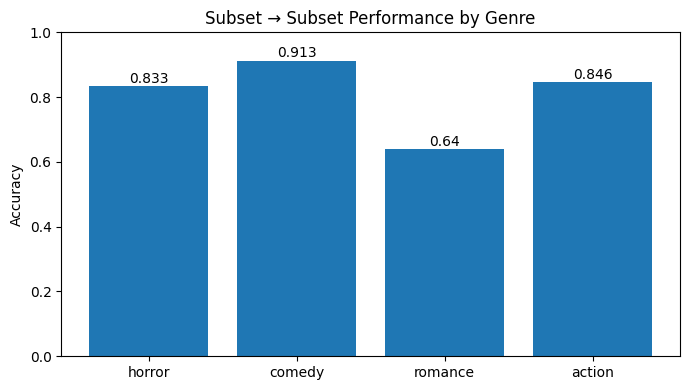

In [80]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

plt.figure(figsize=(7,4))

bars = plt.bar(results_df["genre"], results_df["acc_in_domain"])

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Subset → Subset Performance by Genre")

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, round(height, 3), ha='center')

# Save figure
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "subset_to_subset_accuracy_by_genre.png"), dpi=300, bbox_inches="tight")
plt.show()


#### Analysis of `Subset → Subset Performance by Genre` Graph

In-domain accuracy differs noticeably across genres. Comedy performs the best (0.913), suggesting that sentiment in comedy reviews is often expressed clearly and directly. Words like “funny” or “hilarious” likely provide strong signals for the model.

Horror (0.833) and action (0.846) show moderate performance. These genres use emotionally intense words, but some of these terms can carry different meanings depending on context. As a result, classification is somewhat less straightforward.

Romance performs substantially lower (0.640). This may reflect more subtle or nuanced language, where sentiment is expressed indirectly. Overall, the results suggest that some genres provide clearer sentiment cues than others, even before considering cross-domain transfer.

## 7. Setting C — General → Subset (Cross-Domain Transfer)

In this setting, we evaluate the general model (trained on the full IMDB training data) on each genre-specific test set constructed in Setting B.

Importantly, we use the exact same test observations as in the Subset → Subset experiment. This ensures that any performance difference is due to the training data, not differences in the evaluation sample.

Here, the model is trained on a broader distribution of reviews but tested on genre-specific language. If accuracy falls relative to the in-domain results, this would indicate that genre-specific vocabulary reduces generalization performance.

By holding the test set constant, this experiment isolates the effect of training distribution differences and provides a clean measure of domain shift.


In [ ]:
for result in results:
    genre = result["genre"]

    # Reuse the SAME test set from Setting B (no re-splitting)
    Xg_test, yg_test = genre_test_sets[genre]

    # Evaluate general model on genre-specific test data
    acc_cross = evaluate(nb_general, vec_general, Xg_test, yg_test, label=f"{genre}: General → Subset")

    result["acc_cross_domain"] = acc_cross
    result["delta_drop"] = result["acc_in_domain"] - acc_cross

# Convert to tidy results table
results_df = pd.DataFrame(results).sort_values("delta_drop", ascending=False)

print("\nSummary Results:")
print(results_df)



--- horror: General → Subset ---
Accuracy: 0.9551
              precision    recall  f1-score   support

    negative       0.93      0.99      0.96        82
    positive       0.99      0.92      0.95        74

    accuracy                           0.96       156
   macro avg       0.96      0.95      0.95       156
weighted avg       0.96      0.96      0.96       156


--- comedy: General → Subset ---
Accuracy: 0.9526
              precision    recall  f1-score   support

    negative       0.94      0.97      0.95       124
    positive       0.97      0.94      0.95       129

    accuracy                           0.95       253
   macro avg       0.95      0.95      0.95       253
weighted avg       0.95      0.95      0.95       253


--- romance: General → Subset ---
Accuracy: 0.9767
              precision    recall  f1-score   support

    negative       0.97      0.97      0.97        35
    positive       0.98      0.98      0.98        51

    accuracy                

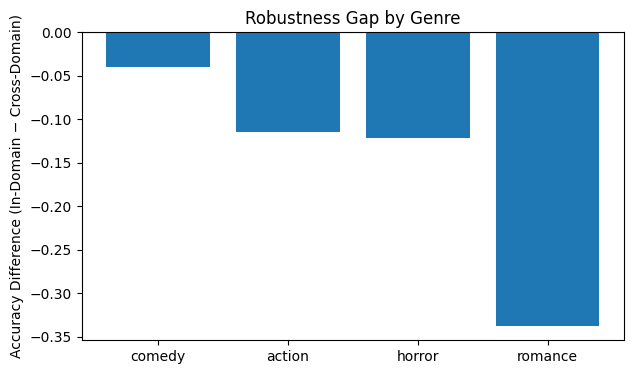

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(results_df["genre"], results_df["delta_drop"])
plt.axhline(0, linestyle="--")  # reference line

plt.ylabel("Accuracy Difference (In-Domain − Cross-Domain)")
plt.title("Robustness Gap by Genre")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robustness_gap_by_genre.png"), dpi=300, bbox_inches="tight")
plt.show()

#### Analysis of `Robustness Gap by Genre` Graph

The robustness gap shows the difference between in-domain and cross-domain accuracy. Negative values mean that the general model performs better than the genre-specific model. In this case, the gap is negative for every genre. This suggests that testing the general model on genre subsets does not reduce performance. Instead, training on the full dataset improves results.

The size of the gap varies by genre. Romance shows the largest difference, where the subset-only model performs much worse than the general model. This likely reflects the smaller training sample available within that genre. The general model benefits from having seen more varied examples, which helps it recognize sentiment even in narrower contexts.

Overall, the results suggest that having more diverse training data improves stability and accuracy. In this experiment, data breadth appears to matter more than strict genre alignment.


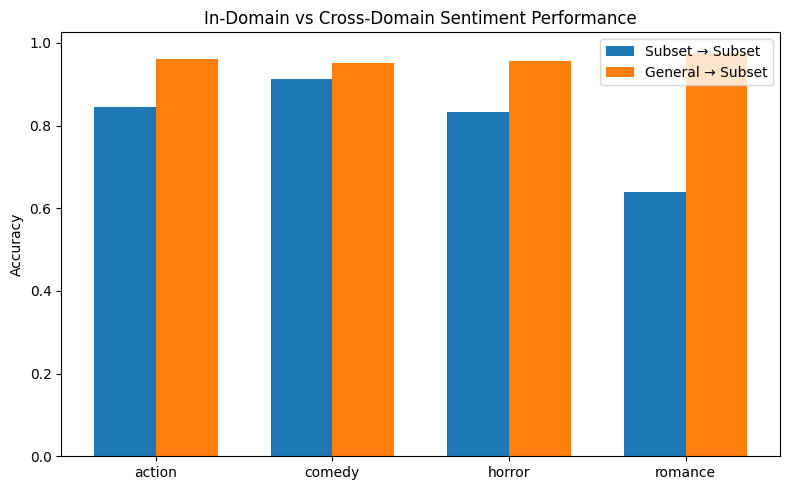

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Sort for consistent ordering
results_plot = results_df.sort_values("genre")

genres = results_plot["genre"]
acc_in = results_plot["acc_in_domain"]
acc_cross = results_plot["acc_cross_domain"]

x = np.arange(len(genres))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, acc_in, width, label="Subset → Subset")
plt.bar(x + width/2, acc_cross, width, label="General → Subset")

plt.xticks(x, genres)
plt.ylabel("Accuracy")
plt.title("In-Domain vs Cross-Domain Sentiment Performance")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "in_vs_cross_domain_accuracy_by_genre.png"), dpi=300, bbox_inches="tight")
plt.show()


#### Analysis of `In-Domain vs Cross-Domain Sentiment Performance` Graph

The cross-domain results differ from the original expectation. Instead of seeing lower accuracy when applying the general model to genre-specific subsets, performance is consistently higher under the General → Subset setting. This suggests that training on the full dataset improves performance, even when the test data comes from a narrower genre.

The size of this difference varies across genres. Romance shows the largest gap, where the subset-only model performs much worse than the general model. This likely reflects the smaller training sample within that genre. With more data and more varied examples, the general model is better able to recognize sentiment patterns.

Overall, the results indicate that broader training data improves stability and generalization. In this experiment, having more diverse examples matters more than training strictly within a single genre.

## 9. Model Interpretability — Inspecting Learned Tokens

To better understand what the model has learned, we inspect the most influential words for positive and negative sentiment in the general model. Multinomial Naive Bayes assigns a probability to each word given a class. By comparing these class-conditional log probabilities, we can identify which tokens most strongly push predictions toward positive or negative sentiment.

This analysis helps answer an important question: **Is the model relying primarily on clear evaluative words (e.g., "excellent", "boring"), or is it sensitive to genre-specific language?**

Examining these top tokens provides qualitative insight into how the classifier makes decisions and complements the quantitative accuracy results shown earlier.


In [84]:
# Inspect which words most strongly influence positive vs negative predictions.
def top_tokens_nb(model, vectorizer, n=15):
    # Return top positive and negative tokens based on NB log-prob differences
    
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    # Difference between log P(word | positive) and log P(word | negative)
    score = model.feature_log_prob_[1] - model.feature_log_prob_[0]
    
    top_pos_idx = np.argsort(score)[-n:][::-1]
    top_neg_idx = np.argsort(score)[:n]
    
    return feature_names[top_pos_idx].tolist(), feature_names[top_neg_idx].tolist()

print("\nGENERAL MODEL — Top Tokens")

gen_pos, gen_neg = top_tokens_nb(nb_general, vec_general, n=15)

print("\nTop Positive Tokens:")
print(gen_pos)

print("\nTop Negative Tokens:")
print(gen_neg)



GENERAL MODEL — Top Tokens

Top Positive Tokens:
['edie', 'mildred', 'welles', 'felix', 'goldsworthy', 'cagney', 'davis', 'lemmon', 'elvira', 'emma', 'matthau', 'carrey', 'tony', 'rea', 'highly recommended']

Top Negative Tokens:
['worst', 'waste', 'waste time', 'redeeming', 'worst movie', 'dahmer', 'awful', 'worse', 'wasted', 'worst movies', 'bad acting', 'pointless', 'don waste', 'crap', 'movie bad']


In [85]:
# Inspect top influential tokens for a single genre-specific model.
analysis_genre = "horror"

subset = get_genre_subset(data, analysis_genre)

if len(subset) > 200:
    Xg = subset["review"].astype(str)
    yg = subset["sentiment"].map({"negative": 0, "positive": 1})

    Xg_train, Xg_test, yg_train, yg_test = train_test_split(Xg, yg, test_size=0.2, random_state=42, stratify=yg)

    # Train genre-specific model
    vec_h, nb_h = train_nb_tfidf(Xg_train, yg_train)

    print(f"\n{analysis_genre.upper()} MODEL — Top Tokens")

    h_pos, h_neg = top_tokens_nb(nb_h, vec_h, n=15)

    print("\nTop Positive Tokens:")
    print(h_pos)

    print("\nTop Negative Tokens:")
    print(h_neg)



HORROR MODEL — Top Tokens

Top Positive Tokens:
['elvira', 'kolchak', 'cell', 'woman black', 'steele', 'castle', 'barbara', 'pet', 'winters', 'pet sematary', 'sematary', 'loved', 'prison', 'barbara steele', 'haunting']

Top Negative Tokens:
['worst', 'cop', 'boring', 'awful', 'crap', 'dahmer', 'waste', 'poorly', 'scary movie', 'bad', 'tom', 'hallam', 'freddy', 'camp', 'terrible']


In [86]:
# Print a few mistakes to understand *why* cross-domain transfer fails
# (e.g., genre-specific words that flip sentiment meaning).
def show_misclassified_examples(texts, y_true, y_pred, k=5, max_chars=400):
    """Print up to k misclassified reviews with true vs predicted labels."""
    
    # Ensure aligned indexing
    texts = texts.reset_index(drop=True)
    y_true = y_true.reset_index(drop=True)
    
    wrong_idx = np.where(y_true.values != y_pred)[0]
    print(f"\nMisclassified: {len(wrong_idx)} / {len(texts)}")

    for i in wrong_idx[:k]:
        true_label = "POS" if y_true.iloc[i] == 1 else "NEG"
        pred_label = "POS" if y_pred[i] == 1 else "NEG"

        print("\n---")
        print(f"True={true_label}, Pred={pred_label}")
        print(texts.iloc[i][:max_chars], "...")

# Cross-domain errors: General model evaluated on genre test set
if len(subset) > 200:
    preds_cross = nb_general.predict(vec_general.transform(Xg_test))

    print(f"\nCROSS-DOMAIN ERRORS (General → {analysis_genre.capitalize()})")
    show_misclassified_examples(Xg_test, yg_test, preds_cross, k=5)



CROSS-DOMAIN ERRORS (General → Horror)

Misclassified: 7 / 156

---
True=POS, Pred=NEG
"The Incredible Melting Man" is a fantastically gross, trashy and energetic Z-grade production that every self-respecting camp-horror freak simply has to see for him/herself! The ideal way to describe this low-budget 70's gem is like a shameless copy of Hammer's "The Quatermass Xperiment" ...only a thousand times filthier! Astronaust Steve West is the only survivor of a disastrous space-mission, b ...

---
True=POS, Pred=NEG
Mirage (1990) is a very rare horror/chiller from 1990, released here in the UK on the "New World Video" label.<br /><br />It's a desert based horror film about a group of young friends who are partying for the weekend, only to be killed off one by one by an unknown force who drives a menacing black truck!!! This film has some creepy scenes, and some gore here and there, but i have to say that the  ...

---
True=POS, Pred=NEG
THE DEVIL'S PLAYTHING is my second attempt at a Joseph

#### Analysis of Cross-Domain Errors (General → Horror)

Most misclassified examples follow a consistent pattern: positive horror reviews are predicted as negative. Many of these reviews contain words such as “gross,” “gore,” “filthier,” or “devil,” which typically signal negative sentiment in general movie reviews. However, within the horror genre, these terms can indicate praise rather than criticism. This suggests that the general model associates emotionally intense or violent vocabulary with negative sentiment, leading to errors when those same words are used positively in genre-specific contexts. These examples provide qualitative evidence of how genre language can shift sentiment interpretation.
